Importing libraries

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Load CIFAR10 Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Sparse Encoder Model

In [3]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

Hyperparameters

In [4]:
model = SparseAutoencoder()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50

Sparsity penalty using KL Divergence

In [5]:
def sparsity_penalty(encoded, rho=0.05, beta=1e-4):

    # Average activation
    rho_hat = torch.mean(torch.sigmoid(encoded), dim=0)

    # Clamp values to avoid log(0)
    rho_hat = torch.clamp(rho_hat, 1e-6, 1 - 1e-6)

    kl_div = rho * torch.log(rho / rho_hat) + \
             (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return beta * torch.sum(kl_div)

Training loop

In [6]:
for epoch in range(num_epochs):

    for images, _ in train_loader:

        images = images.view(images.size(0), -1)

        outputs, encoded = model(images)

        # Reconstruction loss
        recon_loss = criterion(outputs, images)

        # Sparsity penalty
        sparse_loss = sparsity_penalty(encoded)

        # Total loss
        loss = recon_loss + sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/50], Loss: 0.2231
Epoch [2/50], Loss: 0.1970
Epoch [3/50], Loss: 0.1924
Epoch [4/50], Loss: 0.1781
Epoch [5/50], Loss: 0.1631
Epoch [6/50], Loss: 0.1850
Epoch [7/50], Loss: 0.1955
Epoch [8/50], Loss: 0.1939
Epoch [9/50], Loss: 0.1816
Epoch [10/50], Loss: 0.1727
Epoch [11/50], Loss: 0.2164
Epoch [12/50], Loss: 0.1701
Epoch [13/50], Loss: 0.1836
Epoch [14/50], Loss: 0.1812
Epoch [15/50], Loss: 0.1804
Epoch [16/50], Loss: 0.1913
Epoch [17/50], Loss: 0.1847
Epoch [18/50], Loss: 0.1621
Epoch [19/50], Loss: 0.1700
Epoch [20/50], Loss: 0.1908
Epoch [21/50], Loss: 0.1811
Epoch [22/50], Loss: 0.1860
Epoch [23/50], Loss: 0.1859
Epoch [24/50], Loss: 0.1806
Epoch [25/50], Loss: 0.1648
Epoch [26/50], Loss: 0.1608
Epoch [27/50], Loss: 0.1858
Epoch [28/50], Loss: 0.1613
Epoch [29/50], Loss: 0.1793
Epoch [30/50], Loss: 0.1931
Epoch [31/50], Loss: 0.1821
Epoch [32/50], Loss: 0.2033
Epoch [33/50], Loss: 0.2021
Epoch [34/50], Loss: 0.1725
Epoch [35/50], Loss: 0.1557
Epoch [36/50], Loss: 0.1730
E

Test Reconstruction

In [7]:
model.eval()

test_loss = 0

with torch.no_grad():
    for images, _ in test_loader:

        images = images.view(images.size(0), -1)

        outputs, _ = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)

print("Average Test Reconstruction Loss:", avg_test_loss)

Average Test Reconstruction Loss: 0.16581661678567716


Reconstruction Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7411765..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.7254902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.654902].


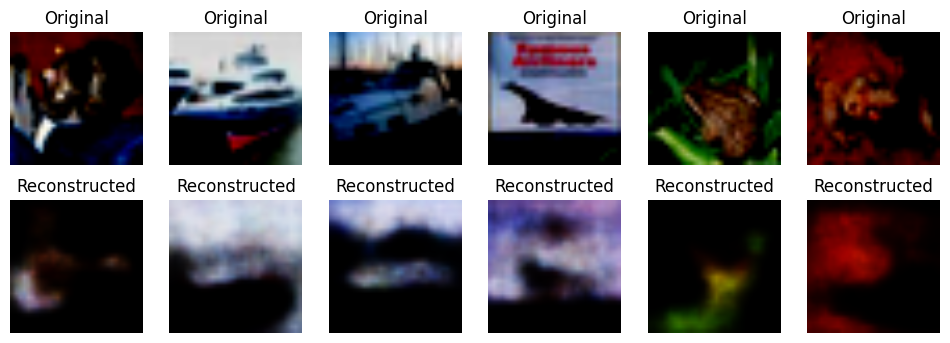

In [8]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

# Flatten images for autoencoder
images_flat = images.view(images.size(0), -1)

# Get reconstructed images
outputs, _ = model(images_flat)

# Reshape back to image format
images = images.view(-1, 3, 32, 32)
outputs = outputs.view(-1, 3, 32, 32)

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):

    # Original images
    axes[0,i].imshow(images[i].permute(1,2,0), interpolation='bilinear')
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    # Reconstructed images
    axes[1,i].imshow(outputs[i].detach().permute(1,2,0), interpolation='bilinear')
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.show()

Conclusion:

The Sparse Autoencoder was successfully implemented and trained on the CIFAR-10 dataset to learn compressed feature representations of images. The model was able to reconstruct images from the learned latent space, demonstrating its ability to capture essential visual patterns despite dimensionality reduction and sparsity constraints. The reconstructed outputs retained general color and structural information, confirming that sparse autoencoders are effective for feature learning and representation compression.